In [1]:
%cd fortran_src
!conda run -n simple_env \
    python3 -m numpy.f2py -c -m \
    wl_saving_conformations \
    wl_saving_conformations.f90 --opt='-O3'
%mkdir -p ../compiled_python_modules
%mv wl_saving_conformations*.so ../compiled_python_modules/
%cd ..


/Users/daviderevignas/scientific_projects/scientific_code/LatPro_reduced/fortran_src
running build
running config_cc
INFO: unifing config_cc, config, build_clib, build_ext, build commands --compiler options
running config_fc
INFO: unifing config_fc, config, build_clib, build_ext, build commands --fcompiler options
running build_src
INFO: build_src
INFO: building extension "wl_saving_conformations" sources
INFO: f2py options: []
INFO: f2py:> /var/folders/n5/f496lkj93z1d5p8bbkfqkhtr0000gn/T/tmpo8u4og5y/src.macosx-11.0-arm64-3.9/wl_saving_conformationsmodule.c
creating /var/folders/n5/f496lkj93z1d5p8bbkfqkhtr0000gn/T/tmpo8u4og5y/src.macosx-11.0-arm64-3.9
Reading fortran codes...
	Reading file 'wl_saving_conformations.f90' (format:free)
Post-processing...
	Block: wl_saving_conformations
			Block: run_wl_low_energy
Applying post-processing hooks...
  character_backward_compatibility_hook
Post-processing (stage 2)...
Building modules...
    Building module "wl_saving_conformations"...
    Ge

In [2]:
import os 
import sys
module_path = "compiled_python_modules/"
sys.path.append(module_path)
import wl_saving_conformations

import numpy as np
import matplotlib.pyplot as plt

from general_python_module import *

### Load relevant variables

In [3]:
MJ_tab_6 = load_MJ_tab_6() # conventional order of amino acids given by num_to_letter_map variable
hamiltonian_walks_contacts=load_hamiltonian_walks_contacts()
hamiltonian_walks_max_abs_GE=load_hamiltonian_walks_max_abs_GE()
hamiltonian_walks_i1_i2=load_hamiltonian_walks_maGE_loop_i1_i2()
hamiltonian_walks_maGE_thread_is_N=load_hamiltonian_walks_maGE_thread_is_N()


In [4]:
i_struct=897
i_seq=0

print(f'The GE of structure {i_struct:} is {hamiltonian_walks_max_abs_GE[i_struct-1]:4.3f}.')

native_contacts=hamiltonian_walks_contacts[i_struct-1]
number_of_native_contacts=len(native_contacts)

print(f"Structure {i_struct:} is characterized by these contacts:")
print(f"{native_contacts[0]:} {native_contacts[1]:} ... {native_contacts[-2]:} {native_contacts[-1]:}")

numeric_msa=np.loadtxt(f"data/sequences_data/z_score_opt_sequences/struct_{i_struct:06d}/numeric_msa.txt",dtype=np.int32)
sequence=numeric_msa[0,:]
letters_sequence="".join([num_to_letter_map[v-1] for v in sequence])

print(f'The selected sequence is {letters_sequence:}.')



The GE of structure 897 is 0.700.
Structure 897 is characterized by these contacts:
[1 6] [ 1 22] ... [17 20] [18 27]
The selected sequence is WQKGDMMKGGDWWKAVKGTDYMLAMSG.


### Set the simulation variables
Here we set the variables of the actual refolding simulations. 
The

In [ ]:
n_temperatures_to_do=11
min_temperature=0.1
max_temperature=0.3
temperatures_to_do=np.linspace(min_temperature,max_temperature,n_temperatures_to_do)
n_initial_saw_steps = 100000

n_refolding_steps=int(1e6)
n_refolding_savings=200
n_monomers=len(sequence)
n_indepentend_refolding_runs_each_temperature = 2
prng_seed=np.random.randint(10,10000000)




In [16]:

(   all_rep_obtained_contacts,
    all_rep_obtained_energies,
    all_rep_obtained_natives,
    all_rep_obtained_distances2,
    all_rep_obtained_bond_vectors)=\
    refolding_many_temperatures.run_refolding_simulations(
        n_refolding_steps=n_refolding_steps,
        n_refolding_savings=n_refolding_savings,
        n_monomers=n_monomers,
        n_indepentend_refolding_runs_each_temperature=n_indepentend_refolding_runs_each_temperature,
        prng_seed=prng_seed,
        interaction_matrix=MJ_tab_6,
        number_of_native_contacts=number_of_native_contacts,
        native_contacts=native_contacts,
        sequence=sequence,
        n_temperatures_to_do=n_temperatures_to_do,
        temperatures_to_do=temperatures_to_do,   
        n_initial_saw_steps=n_initial_saw_steps,
    )

Text(0.5, 1.0, 'struct: 897 seq: WQKGDMMKGGDWWKAVKGTDYMLAMSG')

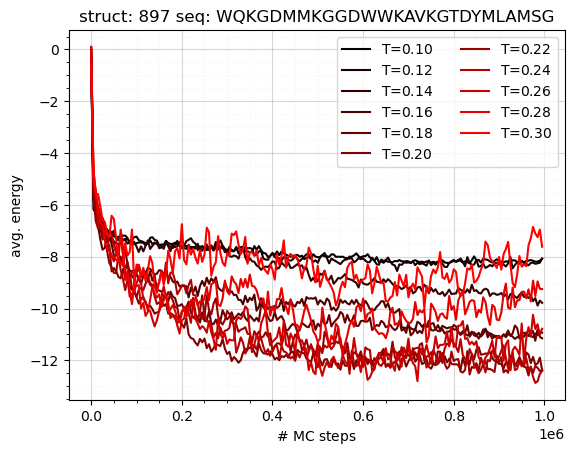

In [26]:
fig,ax=simple_plot_with_grid()

mc_steps_for_plot=np.arange(n_refolding_savings)*(n_refolding_steps//n_refolding_savings)

for i_T in range(n_temperatures_to_do):
    now_color=[i_T/(n_temperatures_to_do-1),0,0]
    ax.plot(mc_steps_for_plot,
            all_rep_obtained_energies[:,:,i_T].mean(axis=1),
            label=f"T=${temperatures_to_do[i_T]:3.2f}$",
            color=now_color)

ax.set_xlabel('$\#$ MC steps')
ax.set_ylabel('avg. energy')
ax.legend(ncols=2)
ax.set_title(f"struct: {i_struct:} seq: {letters_sequence:}")

Text(0.5, 1.0, 'struct: 897 seq: WQKGDMMKGGDWWKAVKGTDYMLAMSG')

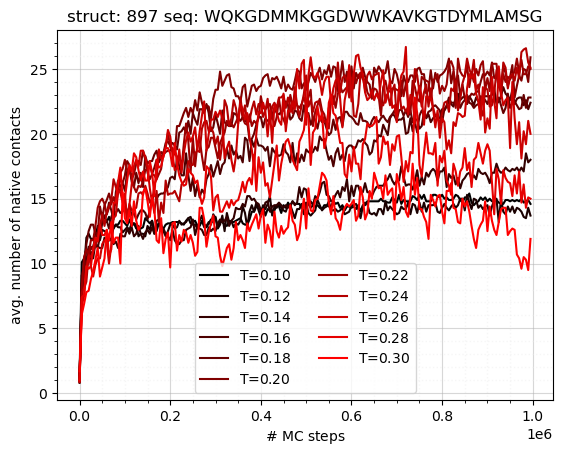

In [28]:
fig,ax=simple_plot_with_grid()


for i_T in range(n_temperatures_to_do):
    now_color=[i_T/(n_temperatures_to_do-1),0,0]
    ax.plot(mc_steps_for_plot,
            all_rep_obtained_natives[:,:,i_T].mean(axis=1),
            label=f"T=${temperatures_to_do[i_T]:3.2f}$",
            color=now_color)

ax.set_xlabel('$\#$ MC steps')
ax.set_ylabel('avg. number of native contacts')
ax.legend(ncols=2)
ax.set_title(f"struct: {i_struct:} seq: {letters_sequence:}")